# Продажи в магазине — прогнозирование временных рядов

https://www.kaggle.com/competitions/store-sales-time-series-forecasting/overview

## Импорт библиотек

In [129]:
!pip install catboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [130]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit


from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import make_scorer

from sklearn.model_selection import RandomizedSearchCV

In [131]:
warnings.filterwarnings('ignore')

## Загрузка данных

In [132]:
train_df = pd.read_csv('../data/train.csv', parse_dates=['date']).drop(columns = "id")
test_df = pd.read_csv("../data/test.csv", parse_dates=["date"])
stores_df = pd.read_csv("../data/stores.csv")
oil_df = pd.read_csv("../data/oil.csv", parse_dates=["date"])
transactions_df = pd.read_csv("../data/transactions.csv", parse_dates=["date"])
holidays_df = pd.read_csv("../data/holidays_events.csv", parse_dates=["date"])
sample_submission = pd.read_csv("../data/sample_submission.csv")

In [133]:
train_df.shape

(3000888, 5)

## Описание данных

In [134]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int64         
 2   family       object        
 3   sales        float64       
 4   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 114.5+ MB


| Поле          | Тип            | Описание                                                                                       |
| ------------- | -------------- | ---------------------------------------------------------------------------------------------- |
| `date`        | datetime64[ns] | Дата продажи. Период: с 2013-01-01 по 2017-08-15.                                              |
| `store_nbr`   | int64          | Номер магазина (идентификатор).                                                                |
| `family`      | object         | Категория товара (например, GROCERY I, AUTOMOTIVE и т. д.).                                    |
| `sales`       | float64        | Количество проданных единиц товара за день. Это целевая переменная (то, что мы предсказываем). |
| `onpromotion` | int64          | Количество товаров этой категории, находящихся в акции в конкретный день и магазине.           |


In [135]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotion  28512 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


| Поле          | Тип            | Описание                                       |
| ------------- | -------------- | ---------------------------------------------- |
| `id`          | int64          | Уникальный идентификатор строки (для сабмита). |
| `date`        | datetime64[ns] | Дата (период: с 2017-08-16 по 2017-08-31).     |
| `store_nbr`   | int64          | Номер магазина.                                |
| `family`      | object         | Категория товара.                              |
| `onpromotion` | int64          | Количество акционных товаров.                  |


In [136]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


| Поле        | Тип    | Описание                                     |
| ----------- | ------ | -------------------------------------------- |
| `store_nbr` | int64  | Идентификатор магазина.                      |
| `city`      | object | Город, где расположен магазин.               |
| `state`     | object | Провинция/регион.                            |
| `type`      | object | Тип магазина (A, B, C, D и т. д.).           |
| `cluster`   | int64  | Группа схожих магазинов по поведению продаж. |


In [137]:
oil_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


| Поле         | Тип            | Описание                                     |
| ------------ | -------------- | -------------------------------------------- |
| `date`       | datetime64[ns] | Дата.                                        |
| `dcoilwtico` | float64        | Цена на нефть WTI в долларах США за баррель. |


In [138]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


| Поле           | Тип            | Описание                        |
| -------------- | -------------- | ------------------------------- |
| `date`         | datetime64[ns] | Дата.                           |
| `store_nbr`    | int64          | Идентификатор магазина.         |
| `transactions` | int64          | Количество покупок в этот день. |


In [139]:
holidays_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


| Поле          | Тип            | Описание                                                              |
| ------------- | -------------- | --------------------------------------------------------------------- |
| `date`        | datetime64[ns] | Дата праздника.                                                       |
| `type`        | object         | Тип события: Holiday, Transfer, Bridge, Work Day, Event и т. д.       |
| `locale`      | object         | Уровень, на котором действует праздник: National, Regional или Local. |
| `locale_name` | object         | Название региона или города, к которому относится праздник.           |
| `description` | object         | Описание события.                                                     |
| `transferred` | bool           | Флаг, показывающий, был ли праздник перенесён на другую дату.         |


## Первичная обработка

### Объединение с тестовым

In [140]:
train_df['id'] = np.nan
test_df['sales'] = np.nan

In [141]:
train_df['is_train'] = 1
test_df['is_train'] = 0

In [142]:
train_df = pd.concat([train_df, test_df], ignore_index=True)

### Обработка цен на нефть

In [143]:
train_df["date"].min(), train_df["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [144]:
data_range = pd.date_range(start=train_df["date"].min(), end=train_df["date"].max(), freq="d")

In [145]:
data_range_df = pd.DataFrame(data_range, columns=['date'])
data_range_df['dcoilwtico'] = np.nan

In [146]:
data_range_df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,NaN
2,2013-01-03,NaN
3,2013-01-04,NaN
4,2013-01-05,NaN


In [147]:
oil_df = data_range_df.merge(oil_df, on='date', how="left")
oil_df = oil_df.drop(columns=['dcoilwtico_x'])
oil_df = oil_df.rename(columns={'dcoilwtico_y': 'dcoilwtico'})

In [148]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-05,NaN


#### Заполнение пропусков

In [149]:
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].interpolate(method="linear").ffill().bfill()

In [150]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,93.140000
1,2013-01-02,93.140000
2,2013-01-03,92.970000
3,2013-01-04,93.120000
4,2013-01-05,93.146667


### Праздники

In [151]:
holidays_df.shape

(350, 6)

In [152]:
holidays_df.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


#### Убираем перенесённые праздники

In [153]:
holidays_df = holidays_df[holidays_df['transferred'] == False]
holidays_df = holidays_df.drop(columns=['transferred', "description"])

In [154]:
holidays_df = holidays_df[~holidays_df['type'].isin(['Bridge', 'Work Day'])]

In [155]:
holidays_df.head()

,date,type,locale,locale_name
0,2012-03-02,Holiday,Local,Manta
1,2012-04-01,Holiday,Regional,Cotopaxi
2,2012-04-12,Holiday,Local,Cuenca
3,2012-04-14,Holiday,Local,Libertad
4,2012-04-21,Holiday,Local,Riobamba


In [156]:
holidays_df.shape

(328, 4)

### Объединение таблиц

In [157]:
df = train_df.copy()

In [158]:
df["is_payday"] = ((df["date"].dt.day == 15) | (df["date"].dt.is_month_end)).astype(int)
df['is_payday_next'] = df['is_payday'].shift(1, fill_value=1)

In [159]:
df['post_earthquake'] = ((df['date'] >= '2016-04-16') & (df['date'] <= '2016-05-15')).astype(int)

In [160]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [161]:
df['day_week'] = df['date'].dt.day_of_week

In [162]:
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

In [163]:
df.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,year,month,day,day_week,week_of_year
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,2013,1,1,1,1
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,2013,1,1,1,1
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,2013,1,1,1,1
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,2013,1,1,1,1
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,2013,1,1,1,1


#### Объединение с магазинами и ценами на нефть

In [164]:
df = (df
      .merge(stores_df, on='store_nbr', how='left')
      .merge(oil_df, on='date', how='left')
      )


In [165]:
df.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,year,month,day,day_week,week_of_year,city,state,type,cluster,dcoilwtico
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,2013,1,1,1,1,Quito,Pichincha,D,13,93.14


#### Объединение с праздниками

In [166]:
holidays_df.head()

,date,type,locale,locale_name
0,2012-03-02,Holiday,Local,Manta
1,2012-04-01,Holiday,Regional,Cotopaxi
2,2012-04-12,Holiday,Local,Cuenca
3,2012-04-14,Holiday,Local,Libertad
4,2012-04-21,Holiday,Local,Riobamba


In [167]:
national = holidays_df[holidays_df['locale'] == 'National']
regional = holidays_df[holidays_df['locale'] == 'Regional']
local = holidays_df[holidays_df['locale'] == 'Local']

In [168]:
national = national[['date', 'type']]
df = df.merge(national, on='date', how='left', suffixes=('', '_national'))
df["holiday_nat"] = df["type_national"].notna().astype(int)
df = df.drop(columns=['type_national'])

In [169]:
regional = regional[['date', 'type', 'locale_name']]
df = df.merge(regional, left_on=['date', "state"], right_on=['date', 'locale_name'], how='left', suffixes=('', '_regional'))
df['holiday_reg'] = df['type_regional'].notna().astype(int)
df = df.drop(columns=['type_regional', "locale_name"])

In [170]:
local = local[['date', 'type', 'locale_name']]
df = df.merge(local, left_on=['date', "city"], right_on=['date', 'locale_name'], how='left', suffixes=('', '_local'))
df['holiday_loc'] = df['type_local'].notna().astype(int)
df = df.drop(columns=['type_local', "locale_name"])

In [171]:
df['is_holiday'] = df[['holiday_nat', 'holiday_reg', 'holiday_loc']].any(axis=1).astype(int)
df = df.drop(columns=['holiday_nat', 'holiday_reg', 'holiday_loc'])

### Обработка основной таблицы

In [172]:
df.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,...,month,day,day_week,week_of_year,city,state,type,cluster,dcoilwtico,is_holiday
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1


In [173]:
df = df.rename(columns ={
               'type': 'store_type',
               'dcoilwtico': 'oil_price'})

#### Приведение типов

In [174]:
object_columns = df.select_dtypes(include=['object']).columns
for col in object_columns:
  df[col] = df[col].astype('string')

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035010 entries, 0 to 3035009
Data columns (total 21 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[ns]
 1   store_nbr        int64         
 2   family           string        
 3   sales            float64       
 4   onpromotion      int64         
 5   id               float64       
 6   is_train         int64         
 7   is_payday        int64         
 8   is_payday_next   int64         
 9   post_earthquake  int64         
 10  year             int32         
 11  month            int32         
 12  day              int32         
 13  day_week         int32         
 14  week_of_year     int64         
 15  city             string        
 16  state            string        
 17  store_type       string        
 18  cluster          int64         
 19  oil_price        float64       
 20  is_holiday       int64         
dtypes: datetime64[ns](1), float64(3

| №  | Название столбца    | Тип данных     | Описание                                                                                                                                                   |
| -- | ------------------- | -------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0  | **date**            | datetime64[ns] | Дата продажи товара в магазине.                                                                                                                            |
| 1  | **store_nbr**       | int64          | Уникальный номер магазина.                                                                                                                                 |
| 2  | **family**          | string         | Категория товара                                                                                             |
| 3  | **sales**           | float64        | Объём продаж товара (в тысячах единиц). **Целевая переменная**; в тестовой выборке отсутствует (`NaN`).                                                    |
| 4  | **onpromotion**     | int64          | Количество единиц товара, участвовавших в акции в указанный день.                                                                                          |
| 5  | **id**              | float64        | Служебный признак |
| 6  | **is_train**        | int64          | Служебный признак: `1` — строка относится к обучающей выборке, `0` — к тестовой.                                                                           |
| 7  | **is_payday**       | int64          | Признак дня зарплаты: `1` — 15-е число или последний день месяца, `0` — остальные дни.                                                                     |
| 8  | **is_payday_next**  | int64          | Признак дня после зарплаты: `1` — предыдущий день был зарплатным, `0` — иначе.                                                                             |
| 9  | **post_earthquake** | int64          | Признак периода после землетрясения 16 апреля 2016 года: `1` — период влияния, `0` — иначе.                                                                |
| 10 | **year**            | int32          | Год продажи.                                                                                                                                               |
| 11 | **month**           | int32          | Месяц продажи.                                                                                                                                             |
| 12 | **day**             | int32          | День месяца.                                                                                                                                               |
| 13 | **day_week**        | int32          | День недели (0 — понедельник, 6 — воскресенье).                                                                                                            |
| 14 | **week_of_year**    | int64          | Номер недели в году.                                                                                                                                       |
| 15 | **city**            | string         | Город, в котором расположен магазин.                                                                                                                       |
| 16 | **state**           | string         | Регион (штат), к которому относится город.                                                                                                                 |
| 17 | **store_type**      | string         | Тип магазина (*A*, *B*, *C*, *D*).                                                                                                                         |
| 18 | **cluster**         | int64          | Кластер магазина по совокупности характеристик.                                                                                                            |
| 19 | **oil_price**       | float64        | Цена нефти (*dcoilwtico*) на соответствующую дату.                                                                                                         |
| 20 | **is_holiday**      | int64          | Признак праздничного дня: `1` — праздник (национальный, региональный или локальный), `0` — обычный день.                                                   |


#### Проверка на пропуски

In [176]:
df.isnull().sum()

date                     0
store_nbr                0
family                   0
sales                28512
onpromotion              0
id                 3006498
is_train                 0
is_payday                0
is_payday_next           0
post_earthquake          0
year                     0
month                    0
day                      0
day_week                 0
week_of_year             0
city                     0
state                    0
store_type               0
cluster                  0
oil_price                0
is_holiday               0
dtype: int64

In [177]:
df.isna().sum()

date                     0
store_nbr                0
family                   0
sales                28512
onpromotion              0
id                 3006498
is_train                 0
is_payday                0
is_payday_next           0
post_earthquake          0
year                     0
month                    0
day                      0
day_week                 0
week_of_year             0
city                     0
state                    0
store_type               0
cluster                  0
oil_price                0
is_holiday               0
dtype: int64

Пропуски в id - это весь тренировочный набор
Пропуски в sales - это весь тестовый набор

#### Проверка на дупликаты

In [178]:
df.shape

(3035010, 21)

In [179]:
df.duplicated().sum()

np.int64(5610)

In [180]:
df = df.drop_duplicates().reset_index(drop=True)

In [181]:
df.duplicated().sum()

np.int64(0)

In [182]:
df.shape

(3029400, 21)

## Визуализация

In [183]:
df.describe()

,date,store_nbr,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,year,month,day,day_week,week_of_year,cluster,oil_price,is_holiday
count,3029400,3.029400e+06,3.000888e+06,3.029400e+06,2.851200e+04,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06
mean,2015-05-02 08:56:11.294118144,2.750000e+01,3.577757e+02,2.643830e+00,3.015144e+06,9.905882e-01,6.588235e-02,6.588235e-02,1.764706e-02,2.014858e+03,6.224706e+00,1.570412e+01,2.996471e+00,2.532471e+01,8.481481e+00,6.769961e+01,8.002179e-02
min,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,3.000888e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.013000e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.619000e+01,0.000000e+00
25%,2014-03-02 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00,3.008016e+06,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.014000e+03,3.000000e+00,8.000000e+00,1.000000e+00,1.300000e+01,4.000000e+00,4.640000e+01,0.000000e+00
50%,2015-05-02 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00,3.015144e+06,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.015000e+03,6.000000e+00,1.600000e+01,3.000000e+00,2.500000e+01,8.500000e+00,5.320000e+01,0.000000e+00
75%,2016-07-01 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00,3.022271e+06,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.016000e+03,9.000000e+00,2.300000e+01,5.000000e+00,3.700000e+01,1.300000e+01,9.569000e+01,0.000000e+00
max,2017-08-31 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,3.029399e+06,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.017000e+03,1.200000e+01,3.100000e+01,6.000000e+00,5.300000e+01,1.700000e+01,1.106200e+02,1.000000e+00
std,NaN,1.558579e+01,1.101998e+03,1.233287e+01,8.230850e+03,9.655665e-02,2.480764e-01,2.480764e-01,1.316649e-01,1.355346e+00,3.374138e+00,8.797600e+00,1.999703e+00,1.474898e+01,4.649735e+00,2.564099e+01,2.713270e-01


### Зависимость цены на нефть от даты

In [184]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,93.140000
1,2013-01-02,93.140000
2,2013-01-03,92.970000
3,2013-01-04,93.120000
4,2013-01-05,93.146667


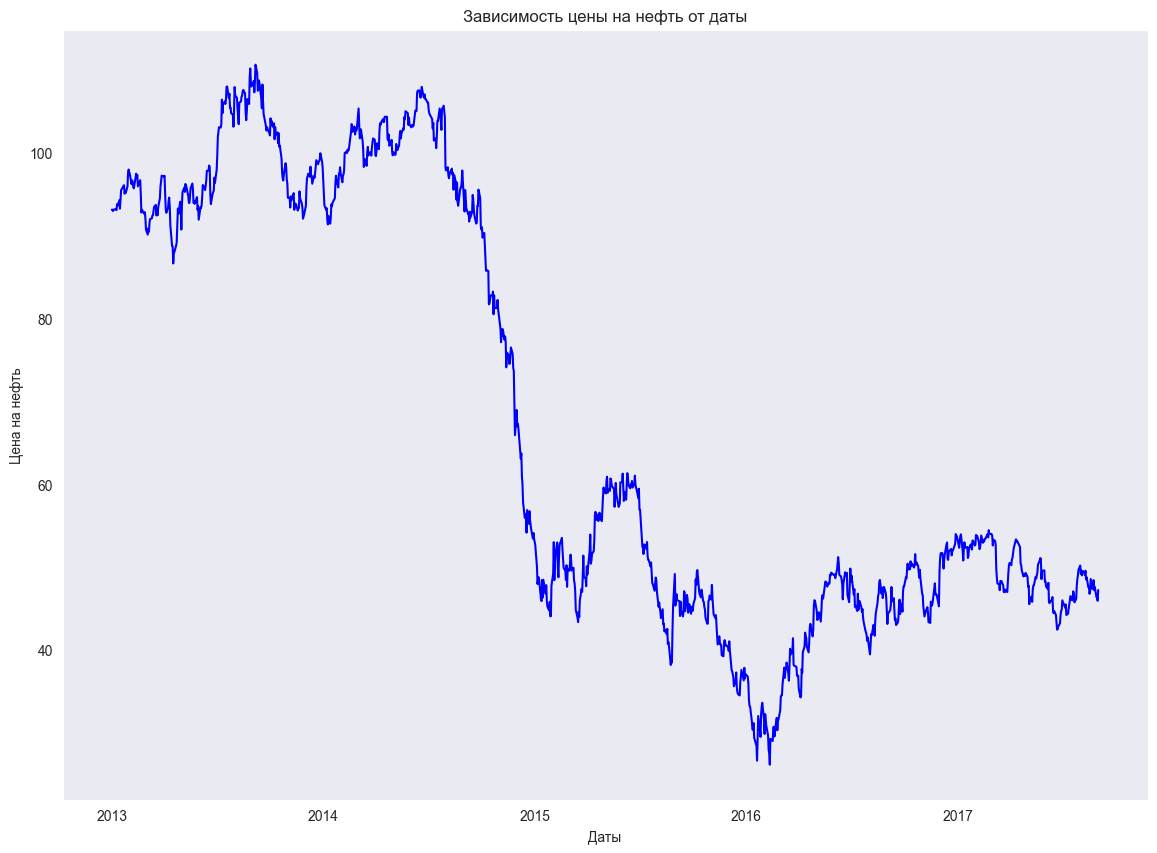

In [185]:
plt.figure(figsize=(14, 10))
plt.plot(oil_df['date'], oil_df["dcoilwtico"], color='blue')
plt.title("Зависимость цены на нефть от даты")
plt.xlabel("Даты")
plt.ylabel('Цена на нефть')
plt.grid()
plt.show()

### Зависимость объёма продаж от типа магазина

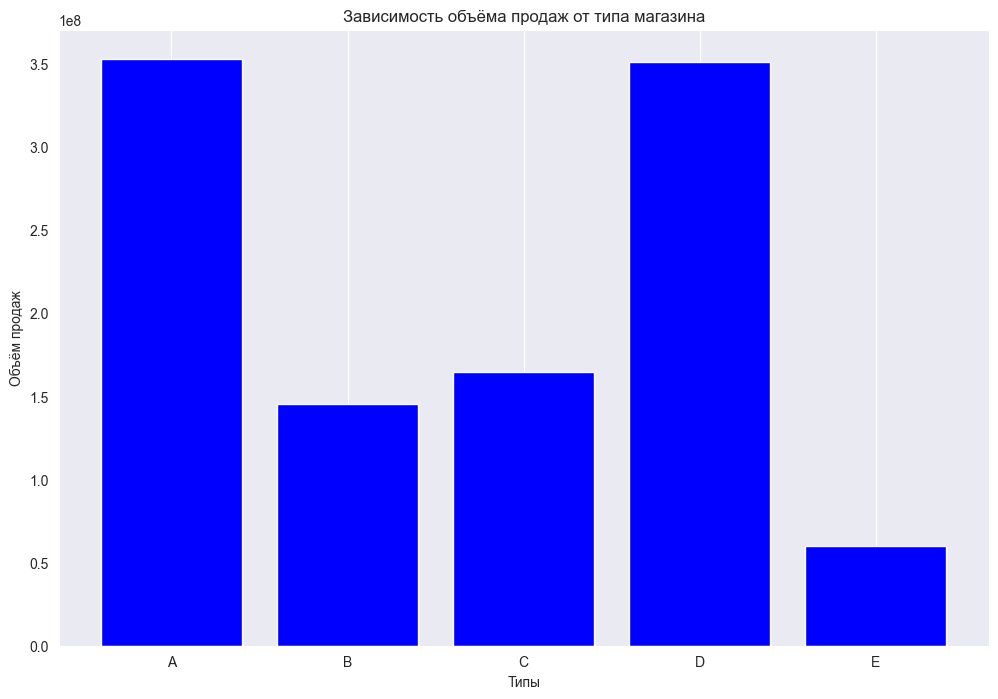

In [186]:
plt.figure(figsize=(12, 8))

data_sales_type = df.groupby('store_type')['sales'].sum()

plt.bar(data_sales_type.index, data_sales_type.values, color='blue')
plt.title("Зависимость объёма продаж от типа магазина")
plt.xlabel("Типы")
plt.ylabel('Объём продаж')
plt.grid(axis='y')
plt.show()

### Зависимость объёма продаж от кластера

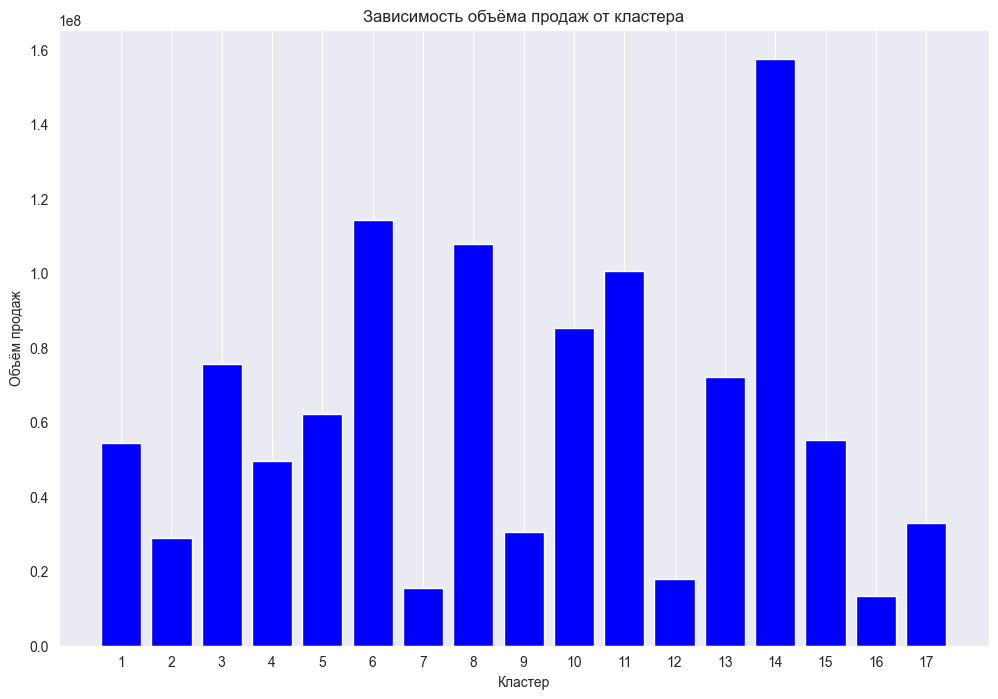

In [187]:
plt.figure(figsize=(12, 8))

data_sales_type = df.groupby('cluster')['sales'].sum()

plt.bar(data_sales_type.index, data_sales_type.values, color='blue')
plt.title("Зависимость объёма продаж от кластера")
plt.xlabel("Кластер")
plt.ylabel('Объём продаж')
plt.grid(axis='y')
plt.xticks(np.arange(1, 18))
plt.show()

### Зависимость объёма продаж от рекламы

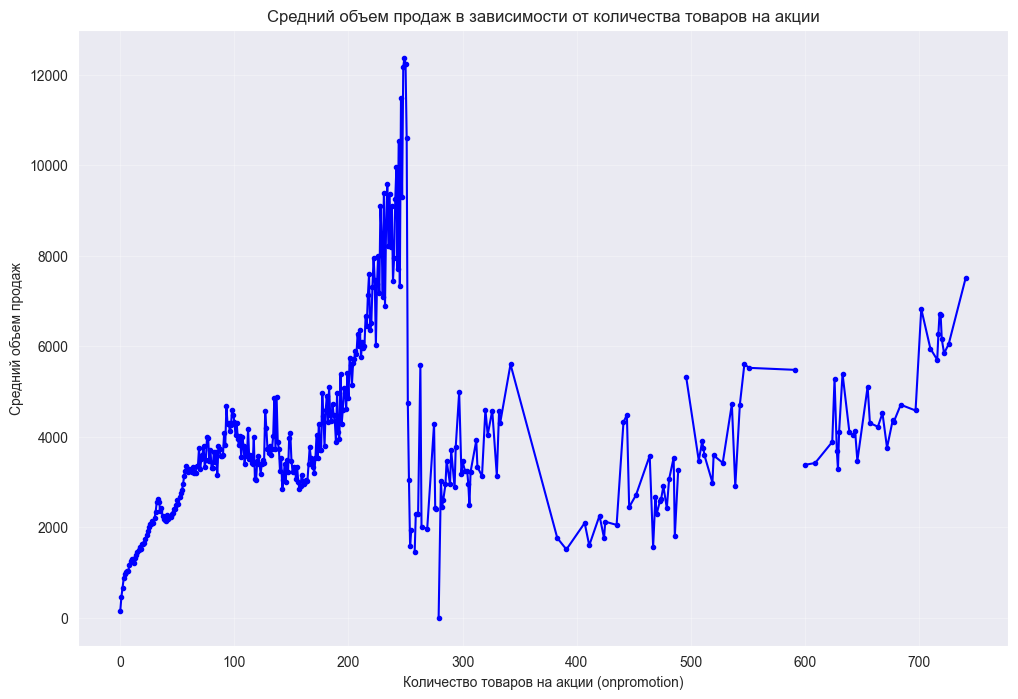

In [188]:
plt.figure(figsize=(12, 8))

promotion_sales = df.groupby('onpromotion')['sales'].mean().reset_index()

plt.plot(promotion_sales['onpromotion'], promotion_sales['sales'], 'o-', markersize = 3, color='blue')
plt.title('Средний объем продаж в зависимости от количества товаров на акции')
plt.xlabel('Количество товаров на акции (onpromotion)')
plt.ylabel('Средний объем продаж')
plt.grid(alpha=0.3)
plt.show()

### Объём продаж по дате

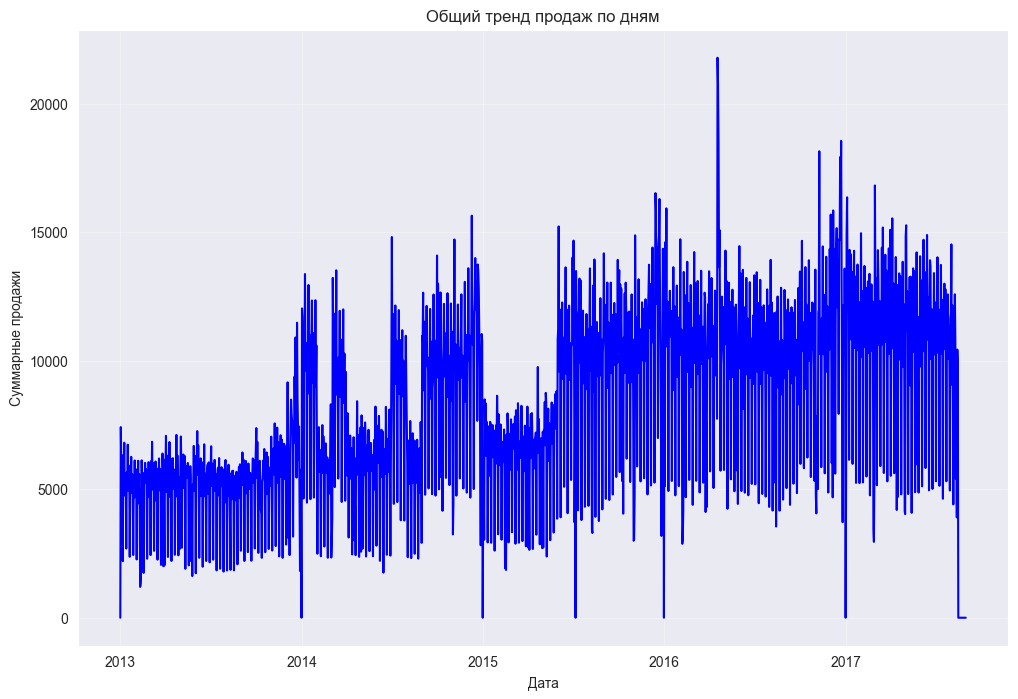

In [189]:
plt.figure(figsize=(12, 8))

date_sales = df[df['store_nbr'] == 1].groupby('date')['sales'].sum().reset_index()

plt.plot(date_sales['date'], date_sales['sales'], markersize = 3, color='blue')
plt.title('Общий тренд продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Суммарные продажи')
plt.grid(alpha=0.3)
plt.show()

### Продажи от дня недели

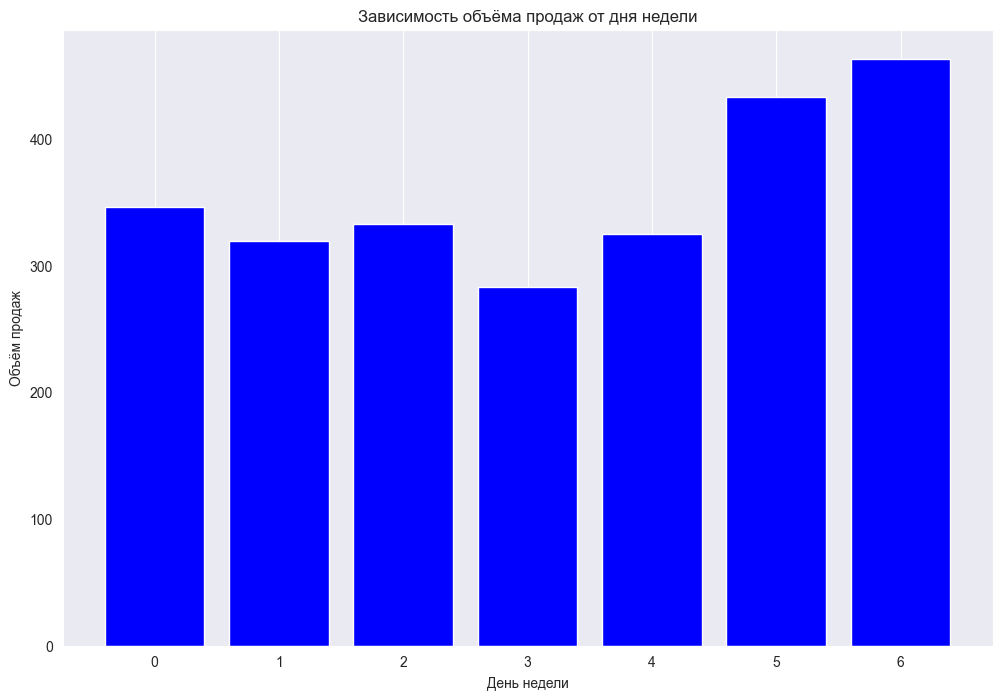

In [190]:
plt.figure(figsize=(12, 8))

data_sales_type = df.groupby('day_week')['sales'].mean()

plt.bar(data_sales_type.index, data_sales_type.values, color='blue')
plt.title("Зависимость объёма продаж от дня недели")
plt.xlabel("День недели")
plt.ylabel('Объём продаж')
plt.grid(axis='y')
plt.show()

### Матрица корреляций

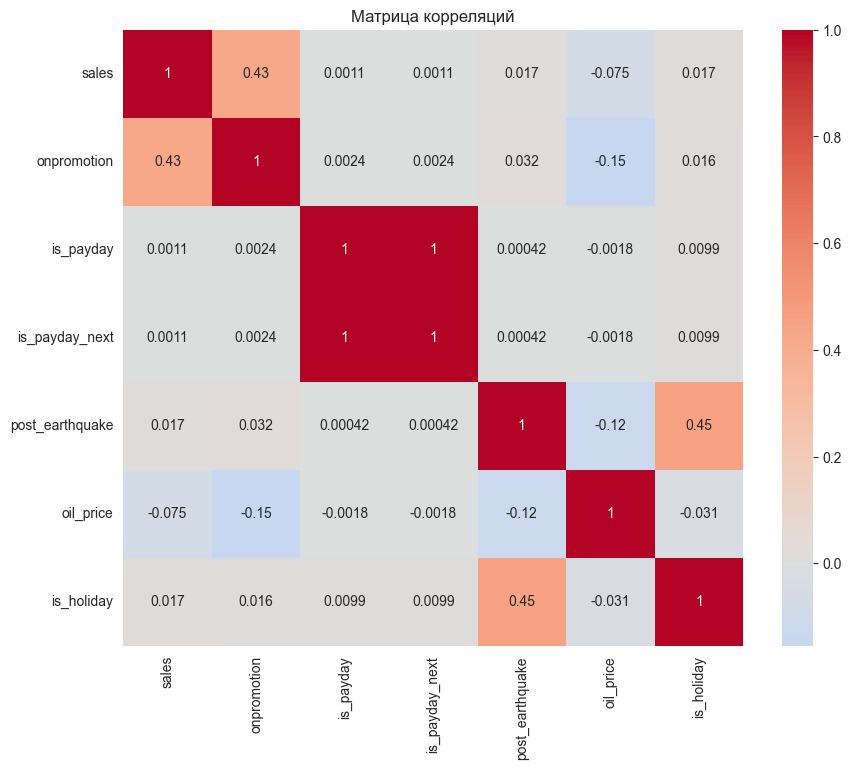

In [191]:
numeric_cols = ['sales', 'onpromotion', 'is_payday', 'is_payday_next',
                'post_earthquake', 'oil_price', 'is_holiday']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.show()

### Топ-10 городов по объему продаж

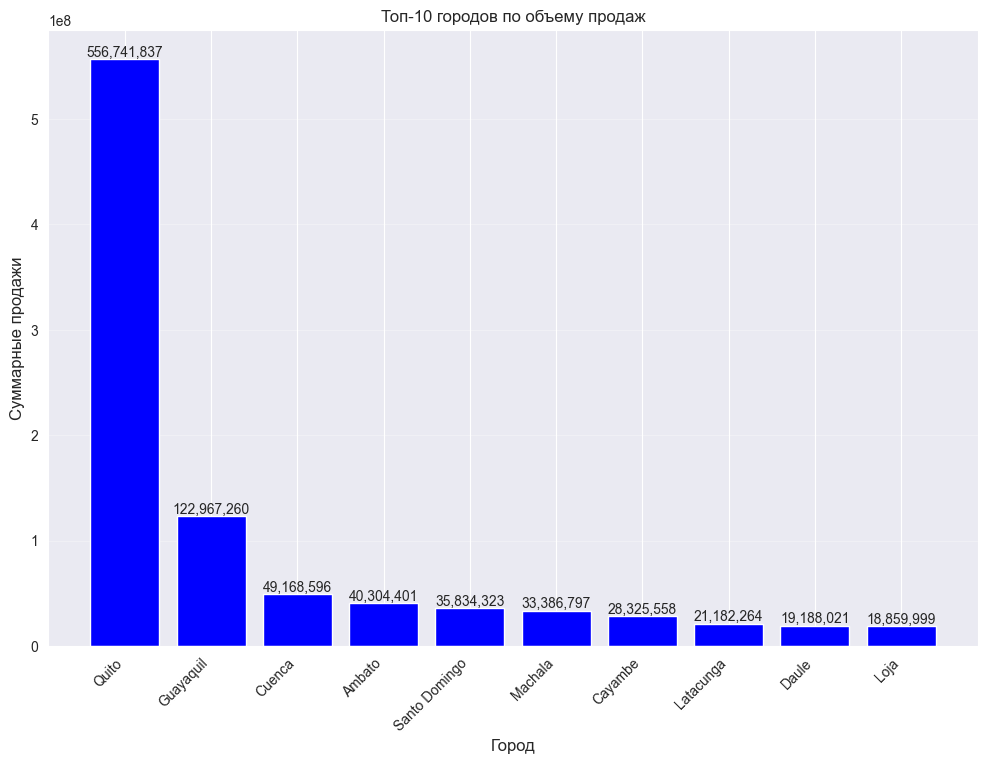

In [192]:
city_sales = df.groupby('city')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
bars = plt.bar(city_sales.index, city_sales.values, color='blue')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}',
             ha='center', va='bottom', fontsize=10)

plt.title('Топ-10 городов по объему продаж')
plt.xlabel('Город', fontsize=12)
plt.ylabel('Суммарные продажи', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [193]:
df.head()

,date,store_nbr,family,sales,onpromotion,id,is_train,is_payday,is_payday_next,post_earthquake,...,month,day,day_week,week_of_year,city,state,store_type,cluster,oil_price,is_holiday
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,1,0,1,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
1,2013-01-01,1,BABY CARE,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
2,2013-01-01,1,BEAUTY,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
3,2013-01-01,1,BEVERAGES,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1
4,2013-01-01,1,BOOKS,0.0,0,NaN,1,0,0,0,...,1,1,1,1,Quito,Pichincha,D,13,93.14,1


### Сезонность

In [194]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

#### 1. Сезонность по месяцам (усредненная по всем годам)


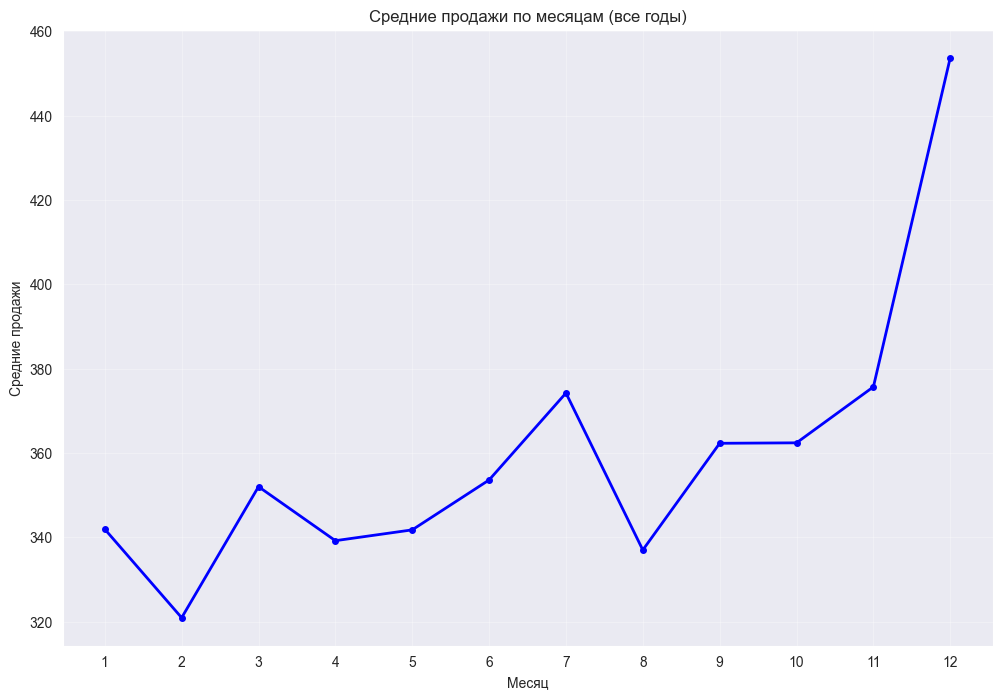

In [195]:
plt.figure(figsize=(12, 8))

monthly_sales = df.groupby('month')['sales'].mean()

plt.plot(monthly_sales.index, monthly_sales.values, 'o-', linewidth=2, markersize=4, color='blue')
plt.title('Средние продажи по месяцам (все годы)')
plt.xlabel('Месяц')
plt.ylabel('Средние продажи')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

#### 2. Сезонность по годам

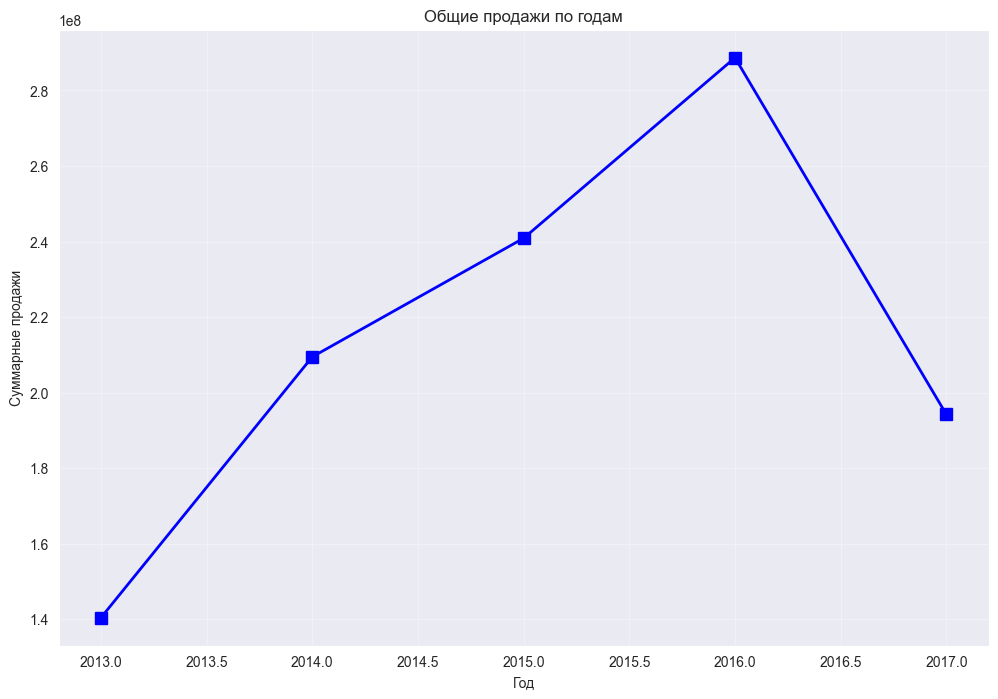

In [196]:
yearly_sales = df.groupby('year')['sales'].sum()

plt.figure(figsize=(12, 8))

plt.plot(yearly_sales.index, yearly_sales.values, 's-', linewidth=2, markersize=8, color='blue')
plt.title('Общие продажи по годам')
plt.xlabel('Год')
plt.ylabel('Суммарные продажи')
plt.grid(alpha=0.3)

#### 3. Зависимость объёма продаж от дня недели

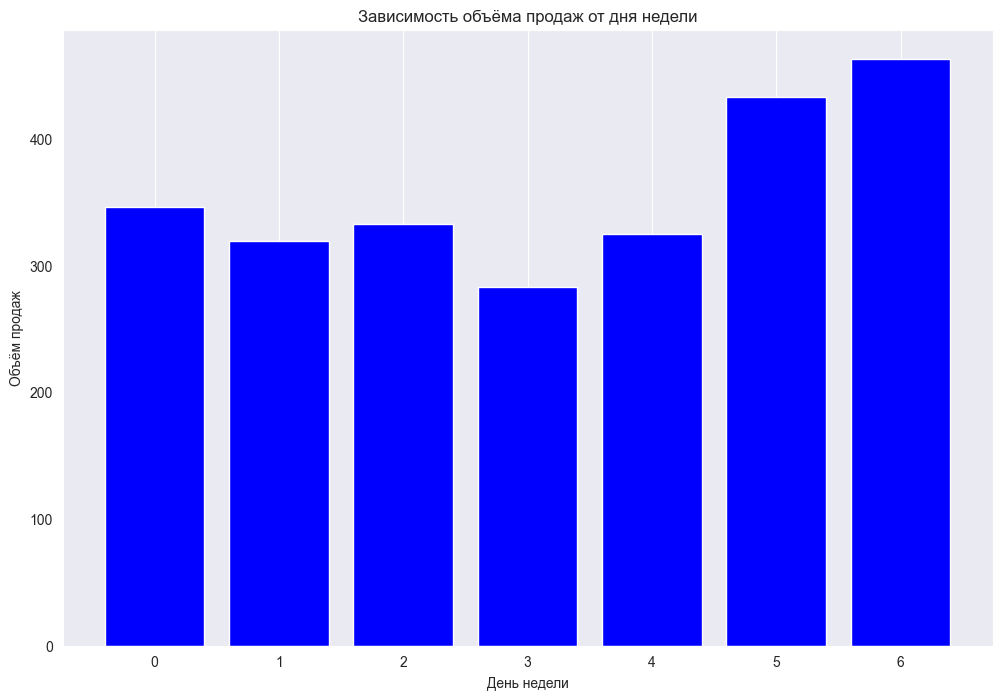

In [197]:
plt.figure(figsize=(12, 8))

data_sales_type = df.groupby('day_week')['sales'].mean()

plt.bar(data_sales_type.index, data_sales_type.values, color='blue')
plt.title("Зависимость объёма продаж от дня недели")
plt.xlabel("День недели")
plt.ylabel('Объём продаж')
plt.grid(axis='y')
plt.show()

#### 4. Cезонность по месяцам и годам (heatmap)


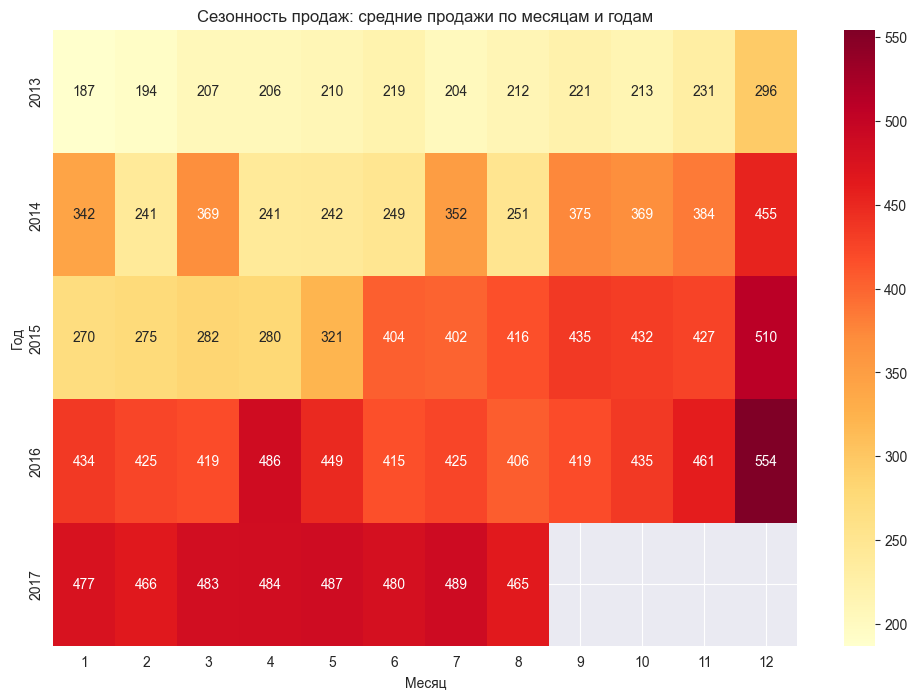

In [198]:
seasonal_pivot = df.pivot_table(values='sales', index='year', columns='month', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(seasonal_pivot, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Сезонность продаж: средние продажи по месяцам и годам')
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.show()

Наблюдается ярко выраженная сезонность с пиком продаж в декабре. Продажи последовательно растут в течение года, начиная с минимальных значений в январе. Сезонные паттерны повторяются из года в год.

## Удаление выбросов

In [199]:
df.shape

(3029400, 21)

In [200]:
# iso = IsolationForest(contamination='auto', random_state=42)

# mask = iso.fit_predict(df[['sales']])
# outliers_mask = mask == -1

# n_outliers = outliers_mask.sum()
# share = n_outliers / len(df)

# n_outliers, share

In [201]:
# for c in [0.005, 0.01, 0.02]:
#     iso = IsolationForest(contamination=c, random_state=42)
#     iso.fit(df[['sales']])
#     print(c, (iso.predict(df[['sales']]) == -1).mean())


In [202]:
# no_nan_mask = df_lagged[num_features].notna().all(axis=1)
# clean_data = df_lagged[num_features][no_nan_mask]
#
# iso_forest = IsolationForest(contamination='auto', random_state=42)
# iso_forest.fit(clean_data)
# outliers = iso_forest.predict(clean_data)
#
# clean_index = clean_data[outliers != -1].index
# df_lagged_filter = df_lagged.loc[clean_index]
#
# df_lagged = pd.concat([df_lagged_filter, df_lagged[~no_nan_mask]], ignore_index=True)
# df_lagged.reset_index(drop=True, inplace=True)
# df_lagged.shape

In [203]:
# # Группируем по city и store_type и считаем медиану sales
# group_medians = df.groupby(['city', 'store_type'])['sales'].median()
# group_medians

In [204]:
# global_median = df['sales'].median()
#
# # Функция для замены выбросов
# def replace_outlier(row, outliers):
#     if outliers[row.name] == -1:  # если выброс
#         # пытаемся взять медиану группы
#         val = group_medians.get((row['city'], row['store_type']), np.nan)
#         # если медиана группы NaN, подставляем глобальную медиану
#         if np.isnan(val):
#             val = global_median
#         return val
#     else:
#         return row['sales']

In [205]:
# global_median = df['sales'].median()
#
# # Функция для замены выбросов
# def replace_outlier(row, outliers):
#     if outliers[row.name] == -1:  # если выброс
#         val = global_median
#         return val
#     else:
#         return row['sales']

In [206]:
# # 1. Берём только тренировочные данные
# train_mask = df['is_train'] == 1
# df_train = df.loc[train_mask].copy()
#
# # 2. Берём только столбец sales для поиска выбросов
# sales_data = df_train[['sales']]
#
# # 3. Обучаем Isolation Forest
# iso = IsolationForest(
#     contamination='auto',  # автоопределение выбросов
#     random_state=42,
#     n_jobs=-1
# )
# iso.fit(sales_data)
#
# # 4. Определяем выбросы
# outliers = iso.predict(sales_data)  # -1 = выброс, 1 = нормальные
#
# # 5. Заменяем выбросы
# df_train['sales'] = df_train.apply(
#     replace_outlier,
#     axis=1,
#     args=(outliers, )
# )
#
# # 6. Объединяем с тестовыми данными без изменений
# df_clean = pd.concat([df_train, df.loc[~train_mask]], axis=0).sort_index()
# df_clean.reset_index(drop=True, inplace=True)
#
# df_clean.shape

In [207]:
# 1. Берём только тренировочные данные
train_mask = df['is_train'] == 1
df_train = df.loc[train_mask].copy()

# 2. Берём только столбец sales для поиска выбросов
sales_data = df_train[['sales']]

# 3. Isolation Forest
iso = IsolationForest(
    contamination='auto',  # автоопределение доли выбросов
    random_state=42,
    n_jobs=-1
)
iso.fit(sales_data)

# 4. Предсказание выбросов
outliers = iso.predict(sales_data)  # -1 = выброс

# 5. Индексы НЕ выбросов
clean_idx = sales_data.index[outliers != -1]

# 6. Оставляем только нормальные строки train
df_train_filtered = df_train.loc[clean_idx]

# 7. Возвращаем test без изменений
df_clean = pd.concat(
    [df_train_filtered, df.loc[~train_mask]],
    axis=0
).sort_index()

df_clean.reset_index(drop=True, inplace=True)
print(df_clean.shape)


(2504267, 21)


In [208]:
df = df_clean.copy()

## Добавление лагов

In [209]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2504267 entries, 0 to 2504266
Data columns (total 21 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   date             2504267 non-null  datetime64[ns]
 1   store_nbr        2504267 non-null  int64         
 2   family           2504267 non-null  string        
 3   sales            2475755 non-null  float64       
 4   onpromotion      2504267 non-null  int64         
 5   id               28512 non-null    float64       
 6   is_train         2504267 non-null  int64         
 7   is_payday        2504267 non-null  int64         
 8   is_payday_next   2504267 non-null  int64         
 9   post_earthquake  2504267 non-null  int64         
 10  year             2504267 non-null  int32         
 11  month            2504267 non-null  int32         
 12  day              2504267 non-null  int32         
 13  day_week         2504267 non-null  int32         
 14  we

### Обработка категорий датасета

In [210]:
categorical_cols = ['store_nbr', 'family', 'city', 'state', 'store_type', 'cluster']
for col in categorical_cols:
    df[col] = df[col].astype('category')


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2504267 entries, 0 to 2504266
Data columns (total 21 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[ns]
 1   store_nbr        category      
 2   family           category      
 3   sales            float64       
 4   onpromotion      int64         
 5   id               float64       
 6   is_train         int64         
 7   is_payday        int64         
 8   is_payday_next   int64         
 9   post_earthquake  int64         
 10  year             int32         
 11  month            int32         
 12  day              int32         
 13  day_week         int32         
 14  week_of_year     int64         
 15  city             category      
 16  state            category      
 17  store_type       category      
 18  cluster          category      
 19  oil_price        float64       
 20  is_holiday       int64         
dtypes: category(6), datetime64[ns](

| №  | Название столбца    | Тип данных     | Описание                                                                                                                                                  |
| -- | ------------------- | -------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0  | **date**            | datetime64[ns] | Дата продажи товара в магазине.                                                                                                                           |
| 1  | **store_nbr**       | category       | Уникальный номер магазина (категориальный признак).                                                                                                       |
| 2  | **family**          | category       | Категория товара (*AUTOMOTIVE*, *BABY CARE* и др.).                                                                                                       |
| 3  | **sales**           | float64        | Объём продаж товара (в тысячах единиц). **Целевая переменная**; в тестовой выборке отсутствует (`NaN`).                                                   |
| 4  | **onpromotion**     | int64          | Количество единиц товара, участвовавших в акции в указанный день.                                                                                         |
| 5  | **id**              | float64        | Идентификатор строки тестовой выборки. Для строк обучающей выборки принимает значение `NaN`. Используется при формировании файла отправки (`submission`). |
| 6  | **is_train**        | int64          | Служебный признак: `1` — строка относится к обучающей выборке, `0` — к тестовой.                                                                          |
| 7  | **is_payday**       | int64          | Признак дня выплаты заработной платы: `1` — 15-е число или последний день месяца, `0` — остальные дни.                                                    |
| 8  | **is_payday_next**  | int64          | Признак дня после зарплаты: `1` — предыдущий день был зарплатным, `0` — иначе.                                                                            |
| 9  | **post_earthquake** | int64          | Признак периода после землетрясения 16 апреля 2016 года: `1` — период влияния, `0` — иначе.                                                               |
| 10 | **year**            | int32          | Год продажи.                                                                                                                                              |
| 11 | **month**           | int32          | Месяц продажи (1–12). Порядковый календарный признак.                                                                                                     |
| 12 | **day**             | int32          | День месяца.                                                                                                                                              |
| 13 | **day_week**        | int32          | День недели (0 — понедельник, 6 — воскресенье). Порядковый признак.                                                                                       |
| 14 | **week_of_year**    | int64          | Номер недели в году.                                                                                                                                      |
| 15 | **city**            | category       | Город, в котором расположен магазин.                                                                                                                      |
| 16 | **state**           | category       | Регион (штат), к которому относится город.                                                                                                                |
| 17 | **store_type**      | category       | Тип магазина (*A*, *B*, *C*, *D*).                                                                                                                        |
| 18 | **cluster**         | category       | Кластер магазина по совокупности характеристик.                                                                                                           |
| 19 | **oil_price**       | float64        | Цена нефти (*dcoilwtico*) на соответствующую дату.                                                                                                        |
| 20 | **is_holiday**      | int64          | Признак праздничного дня: `1` — праздник (национальный, региональный или локальный), `0` — обычный день.                                                  |


### Добавление лагов

In [212]:
df_lagged = df.copy()

In [213]:
# параметры лагов и окон
LAGS = [1, 7, 28]
ROLL_WINDOWS = [7, 28]

# сортировка
df_lagged = df_lagged.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# группировка
g = df_lagged.groupby(['store_nbr', 'family'], observed=False)

# Лаги продаж
for lag in LAGS:
    df_lagged[f'sales_lag_{lag}'] = g['sales'].shift(lag)

# Скользящие средние и стандартное отклонение
for w in ROLL_WINDOWS:
    df_lagged[f'sales_roll_mean_{w}'] = (
        g['sales']
        .shift(1)
        .rolling(window=w, min_periods=1)
        .mean()
        .reset_index(drop=True)
    )
    df_lagged[f'sales_roll_std_{w}'] = (
        g['sales']
        .shift(1)
        .rolling(window=w, min_periods=1)
        .std()
        .fillna(0)
        .reset_index(drop=True)
    )

#  Лаги onpromotion
for lag in [1, 7, 28]:
    df_lagged[f'onpromo_lag_{lag}'] = g['onpromotion'].shift(lag)

#  Кол-во промо за последние дни
for w in [7, 14, 28]:
    df_lagged[f'promo_sum_last_{w}'] = (
        g['onpromotion']
        .shift(1)
        .rolling(window=w, min_periods=1)
        .sum()
        .reset_index(drop=True)
    )

# Лаги для oil_price
for lag in [1, 7, 14, 28]:
    df_lagged[f'oil_price_lag_{lag}'] = df_lagged.groupby(['store_nbr', 'family'])['oil_price'].shift(lag)

# Разницы и относительные изменения
df_lagged['sales_diff_lag1_lag7'] = df_lagged['sales_lag_1'] - df_lagged['sales_lag_7']
df_lagged['sales_pctchg_lag7'] = (df_lagged['sales_lag_1'] - df_lagged['sales_lag_7']) / df_lagged['sales_lag_7'].replace(0, np.nan)
df_lagged['sales_pctchg_lag7'] = df_lagged['sales_pctchg_lag7'].fillna(0)

In [214]:
df_lagged.isnull().sum()

date                          0
store_nbr                     0
family                        0
sales                     28512
onpromotion                   0
id                      2475755
is_train                      0
is_payday                     0
is_payday_next                0
post_earthquake               0
year                          0
month                         0
day                           0
day_week                      0
week_of_year                  0
city                          0
state                         0
store_type                    0
cluster                       0
oil_price                     0
is_holiday                    0
sales_lag_1               28512
sales_lag_7               28512
sales_lag_28              49120
sales_roll_mean_7         17820
sales_roll_std_7              0
sales_roll_mean_28            1
sales_roll_std_28             0
onpromo_lag_1              1782
onpromo_lag_7             12474
onpromo_lag_28            49120
promo_su

In [215]:
# # Заполняем пропуски
# df_lagged[df_lagged.select_dtypes(include=['number']).columns] = (
#     df_lagged.select_dtypes(include=['number']).fillna(0)
# )

In [216]:
df_lagged.columns

Index(['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'id', 'is_train',
       'is_payday', 'is_payday_next', 'post_earthquake', 'year', 'month',
       'day', 'day_week', 'week_of_year', 'city', 'state', 'store_type',
       'cluster', 'oil_price', 'is_holiday', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_28', 'sales_roll_mean_7', 'sales_roll_std_7',
       'sales_roll_mean_28', 'sales_roll_std_28', 'onpromo_lag_1',
       'onpromo_lag_7', 'onpromo_lag_28', 'promo_sum_last_7',
       'promo_sum_last_14', 'promo_sum_last_28', 'oil_price_lag_1',
       'oil_price_lag_7', 'oil_price_lag_14', 'oil_price_lag_28',
       'sales_diff_lag1_lag7', 'sales_pctchg_lag7'],
      dtype='object')

In [217]:
df_lagged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2504267 entries, 0 to 2504266
Data columns (total 40 columns):
 #   Column                Dtype         
---  ------                -----         
 0   date                  datetime64[ns]
 1   store_nbr             category      
 2   family                category      
 3   sales                 float64       
 4   onpromotion           int64         
 5   id                    float64       
 6   is_train              int64         
 7   is_payday             int64         
 8   is_payday_next        int64         
 9   post_earthquake       int64         
 10  year                  int32         
 11  month                 int32         
 12  day                   int32         
 13  day_week              int32         
 14  week_of_year          int64         
 15  city                  category      
 16  state                 category      
 17  store_type            category      
 18  cluster               category      
 19  

## Кодирование

In [218]:
num_features = df_lagged.select_dtypes(include=['float64', 'int32', 'int64']).columns.tolist()
cat_features = df_lagged.select_dtypes(include=['category']).columns.tolist()

In [219]:
num_features.remove('sales')

In [220]:
num_features

['onpromotion',
 'id',
 'is_train',
 'is_payday',
 'is_payday_next',
 'post_earthquake',
 'year',
 'month',
 'day',
 'day_week',
 'week_of_year',
 'oil_price',
 'is_holiday',
 'sales_lag_1',
 'sales_lag_7',
 'sales_lag_28',
 'sales_roll_mean_7',
 'sales_roll_std_7',
 'sales_roll_mean_28',
 'sales_roll_std_28',
 'onpromo_lag_1',
 'onpromo_lag_7',
 'onpromo_lag_28',
 'promo_sum_last_7',
 'promo_sum_last_14',
 'promo_sum_last_28',
 'oil_price_lag_1',
 'oil_price_lag_7',
 'oil_price_lag_14',
 'oil_price_lag_28',
 'sales_diff_lag1_lag7',
 'sales_pctchg_lag7']

In [221]:
cat_features

['store_nbr', 'family', 'city', 'state', 'store_type', 'cluster']

In [222]:
for col in cat_features:
    n_unique = df_lagged[col].nunique()
    print(f"{col}: {n_unique} уникальных значений")

store_nbr: 54 уникальных значений
family: 33 уникальных значений
city: 22 уникальных значений
state: 16 уникальных значений
store_type: 5 уникальных значений
cluster: 17 уникальных значений


In [223]:
# Кодируем категориальные признаки
for col in cat_features:
    le = LabelEncoder()
    df_lagged[col] = le.fit_transform(df_lagged[col])

In [224]:
# # Признаки для Label Encoding
# label_cols = ['store_nbr', 'family']
#
# # Признаки для One-Hot Encoding
# one_hot_cols = ['city', 'state', 'store_type', 'cluster']

In [225]:
# df_encoded = pd.get_dummies(df_lagged, columns=one_hot_cols, drop_first=False)

In [226]:
# for col in label_cols:
#     le = LabelEncoder()
#     df_encoded[col] = le.fit_transform(df_encoded[col])

one_hot ухудшил точность, так что оставляем LabelEncoder

In [227]:
df_lagged.shape

(2504267, 40)

In [228]:
df_lagged.columns


Index(['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'id', 'is_train',
       'is_payday', 'is_payday_next', 'post_earthquake', 'year', 'month',
       'day', 'day_week', 'week_of_year', 'city', 'state', 'store_type',
       'cluster', 'oil_price', 'is_holiday', 'sales_lag_1', 'sales_lag_7',
       'sales_lag_28', 'sales_roll_mean_7', 'sales_roll_std_7',
       'sales_roll_mean_28', 'sales_roll_std_28', 'onpromo_lag_1',
       'onpromo_lag_7', 'onpromo_lag_28', 'promo_sum_last_7',
       'promo_sum_last_14', 'promo_sum_last_28', 'oil_price_lag_1',
       'oil_price_lag_7', 'oil_price_lag_14', 'oil_price_lag_28',
       'sales_diff_lag1_lag7', 'sales_pctchg_lag7'],
      dtype='object')

## Разделение на тренировочную/тестовую

In [229]:
df_lagged.date.min(), df_lagged.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [230]:
train_df = df_lagged[df_lagged['is_train'] == 1].copy()
test_df  = df_lagged[df_lagged['is_train'] == 0].copy()

train_df.drop(columns=['is_train', 'id'], inplace=True) # Удаляем лишние столбцы (Служебные)
test_df.drop(columns=['is_train', 'sales'], inplace=True)

In [231]:
train_df.date.min(), train_df.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [232]:
test_df.date.min(), test_df.date.max()

(Timestamp('2017-08-16 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [233]:
# Пропуски после добаления лагов
train_df.isna().sum()

date                        0
store_nbr                   0
family                      0
sales                       0
onpromotion                 0
is_payday                   0
is_payday_next              0
post_earthquake             0
year                        0
month                       0
day                         0
day_week                    0
week_of_year                0
city                        0
state                       0
store_type                  0
cluster                     0
oil_price                   0
is_holiday                  0
sales_lag_1              1782
sales_lag_7             12286
sales_lag_28            47013
sales_roll_mean_7        1782
sales_roll_std_7            0
sales_roll_mean_28          1
sales_roll_std_28           0
onpromo_lag_1            1782
onpromo_lag_7           12286
onpromo_lag_28          47013
promo_sum_last_7            1
promo_sum_last_14           1
promo_sum_last_28           1
oil_price_lag_1          1782
oil_price_

### Удаляем пропуски в лагах в train_df

In [234]:
lag_cols = [c for c in train_df.columns if 'lag' in c
            or 'roll' in c
            or 'promo_sum' in c
            or 'diff' in c
            or 'pctchg' in c]

train_df[lag_cols] = train_df[lag_cols].fillna(0)

In [235]:
train_df.isna().sum()

date                    0
store_nbr               0
family                  0
sales                   0
onpromotion             0
is_payday               0
is_payday_next          0
post_earthquake         0
year                    0
month                   0
day                     0
day_week                0
week_of_year            0
city                    0
state                   0
store_type              0
cluster                 0
oil_price               0
is_holiday              0
sales_lag_1             0
sales_lag_7             0
sales_lag_28            0
sales_roll_mean_7       0
sales_roll_std_7        0
sales_roll_mean_28      0
sales_roll_std_28       0
onpromo_lag_1           0
onpromo_lag_7           0
onpromo_lag_28          0
promo_sum_last_7        0
promo_sum_last_14       0
promo_sum_last_28       0
oil_price_lag_1         0
oil_price_lag_7         0
oil_price_lag_14        0
oil_price_lag_28        0
sales_diff_lag1_lag7    0
sales_pctchg_lag7       0
dtype: int64

Теперь нет пропусков

### Разделение на тренировочную/валидацию

In [236]:
test_df.date.min(), test_df.date.max()

(Timestamp('2017-08-16 00:00:00'), Timestamp('2017-08-31 00:00:00'))

In [237]:
train_df.date.min(), train_df.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [238]:
split_date = '2017-08-01' # У валидации такой же размер как у тестовой

# Разделяем по дате
train_split_df = train_df[train_df['date'] < split_date].copy().drop(columns=['date'])
val_split_df   = train_df[train_df['date'] >= split_date].copy().drop(columns=['date'])

In [239]:
test_df.drop(columns=['date'], inplace=True)

In [240]:
train_split_df.shape

(2454682, 37)

In [241]:
val_split_df.shape

(21073, 37)

In [242]:
test_df.shape

(28512, 37)

## Предсказательные модели

### Подготовка для обучения

In [243]:
# Целевой признак
target = 'sales'

# Признаки для модели (все кроме целевого и id, если он есть)
features = [c for c in train_split_df.columns if c != target]

X_train = train_split_df[features]
y_train = train_split_df[target]

X_val = val_split_df[features]
y_val = val_split_df[target]

In [244]:
test_features = [c for c in test_df.columns if c not in ['id', 'sales']]
X_test = test_df[test_features]

In [245]:
len(features)

36

In [246]:
len(test_features)

36

#### Функция оценки точности

In [247]:
def rmsle(y_true, y_pred):
    """
    Вычисляет RMSLE между истинными и предсказанными значениями.
    Отрицательные предсказания обрезаются в 0.
    """
    y_pred = np.maximum(0, y_pred)  # обрезаем отрицательные
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

### Random Forest Regressor

In [248]:
# # Параметры модели
# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42,
#     n_jobs=-1
# )
#
# # Обучаем на тренировочной выборке
# rf.fit(X_train, y_train)
#
# # Предсказания на валидации
# y_val_pred = rf.predict(X_val)
#
# # RMSLE
# rmsle_rf = rmsle(y_val, y_val_pred)
# print(f'RMSLE RF: {rmsle_rf:.5f}')

RMSLE RF: 0.46927

### XGBoost

In [249]:
# Параметры модели
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Обучение
xgb.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_xgb = xgb.predict(X_val)

# RMSLE
rmsle_xgb = rmsle(y_val, y_val_pred_xgb)
print(f'RMSLE XGB: {rmsle_xgb:.5f}')

RMSLE XGB: 0.44338


RMSLE XGB: 0.44338

                 feature    importance
20     sales_roll_mean_7  3.198992e+07
18           sales_lag_7  8.306200e+06
22    sales_roll_mean_28  2.420756e+06
17           sales_lag_1  1.038809e+06
19          sales_lag_28  4.402339e+05
9               day_week  3.077312e+05
7                  month  2.448317e+05
8                    day  1.972098e+05
21      sales_roll_std_7  1.835234e+05
23     sales_roll_std_28  1.426118e+05
4         is_payday_next  1.334873e+05
16            is_holiday  1.333159e+05
10          week_of_year  1.311648e+05
34  sales_diff_lag1_lag7  1.117005e+05
2            onpromotion  1.105876e+05
1                 family  1.032456e+05
35     sales_pctchg_lag7  9.985888e+04
6                   year  9.674238e+04
13            store_type  8.600477e+04
0              store_nbr  8.439413e+04


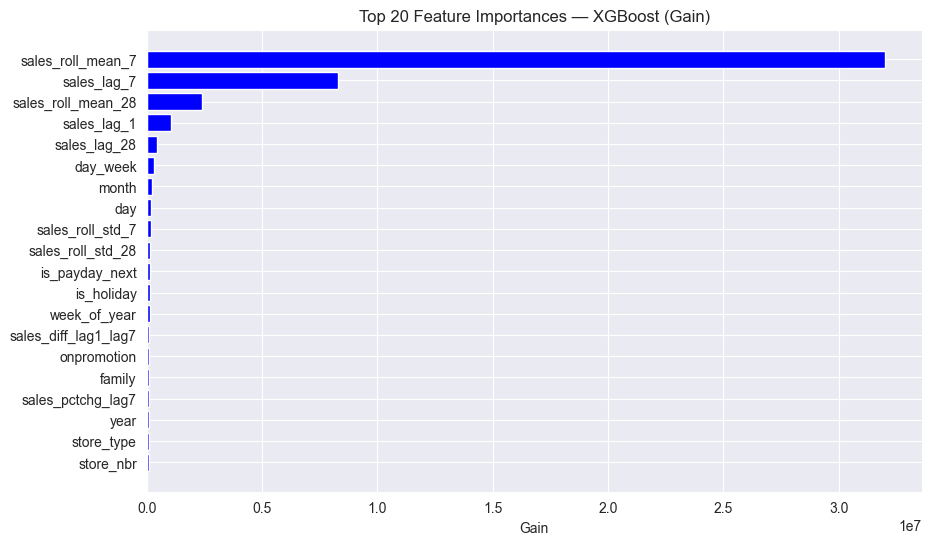

In [250]:
# Получаем важность признаков по gain
gain_importances = xgb.get_booster().get_score(importance_type='gain')

# Переводим в DataFrame
fi_df = pd.DataFrame({
    'feature': list(gain_importances.keys()),
    'importance': list(gain_importances.values())
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(10,6))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='blue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — XGBoost (Gain)')
plt.show()

### HistGradientBoostingRegressor

In [251]:
# Параметры модели
hgb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

# Обучение
hgb.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_hgb = hgb.predict(X_val)

# RMSLE
rmsle_hgb = rmsle(y_val, y_val_pred_hgb)
print(f'RMSLE HGB: {rmsle_hgb:.5f}')

RMSLE HGB: 0.46156


RMSLE HGB: 0.46156

### CatBoost

In [252]:
# Параметры модели
cat = CatBoostRegressor(
    iterations=200,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

# Обучение
cat.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_cat = cat.predict(X_val)

# RMSLE
rmsle_cat = rmsle(y_val, y_val_pred_cat)
print(f'RMSLE CatBoost: {rmsle_cat:.5f}')

RMSLE CatBoost: 0.48658


RMSLE CatBoost: 0.48658

### LightGBM

In [253]:
# Параметры модели
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Обучение
lgbm.fit(X_train, y_train)

# Предсказания на валидации
y_val_pred_lgbm = lgbm.predict(X_val)

# RMSLE
rmsle_lgbm = rmsle(y_val, y_val_pred_lgbm)
print(f'RMSLE LGBM: {rmsle_lgbm:.5f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088686 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4916
[LightGBM] [Info] Number of data points in the train set: 2454682, number of used features: 36
[LightGBM] [Info] Start training from score 46.954628
RMSLE LGBM: 0.45237


RMSLE LGBM: 0.45237

                 feature  importance
9               day_week        2797
1                 family        2288
8                    day        1920
0              store_nbr        1882
22    sales_roll_mean_28        1716
10          week_of_year        1485
17           sales_lag_1        1398
23     sales_roll_std_28        1363
20     sales_roll_mean_7        1313
18           sales_lag_7        1219
21      sales_roll_std_7        1058
2            onpromotion        1054
19          sales_lag_28        1023
7                  month         890
14               cluster         884
34  sales_diff_lag1_lag7         838
30       oil_price_lag_1         768
15             oil_price         746
35     sales_pctchg_lag7         690
11                  city         666


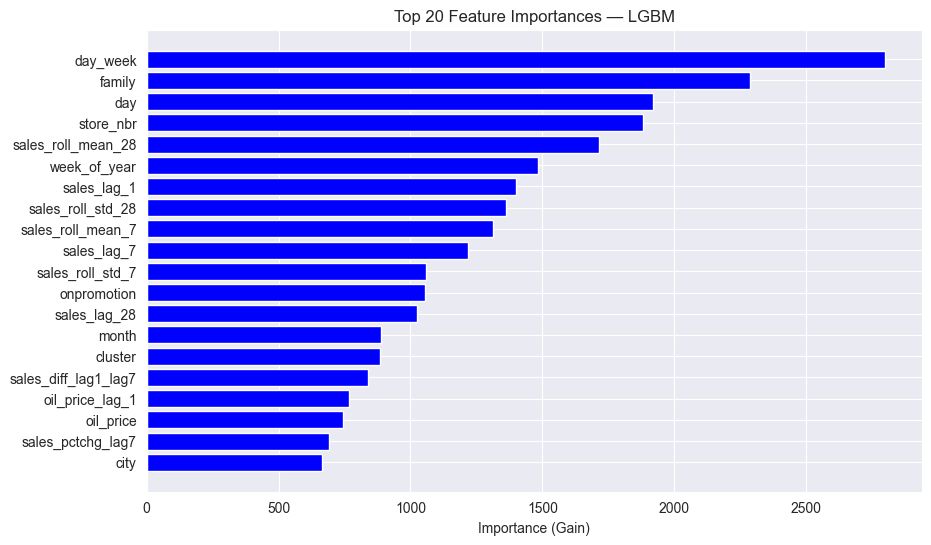

In [254]:
# 1. Получаем важности по gain
feature_importances = lgbm.feature_importances_  # по умолчанию gain
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

# 2. Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# 3. Визуализация
plt.figure(figsize=(10,6))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='blue')
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Feature Importances — LGBM')
plt.show()

### Результаты точности на валидационной выборки

| Модель                        | RMSLE (Validation) |
| ----------------------------- | ------------------ |
| **XGBoost**                   | **0.44338**        |
| LightGBM                      | 0.45237            |
| HistGradientBoostingRegressor | 0.46156            |
| Random Forest Regressor       | 0.46927            |
| CatBoost                      | 0.48658            |


## GridSearch

### GridSearch для XGBoost

In [255]:
# param_grid = {
#     'n_estimators': [200, 300],
#     'max_depth': [4, 6, 8, 10],
#     'learning_rate': [0.05, 0.1, 0,2],
#     'subsample': [0.8, 1],
#     'colsample_bytree': [0.8]
# }
#
# # Модель
# xgb = XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42,
#     n_jobs=-1
# )
#
# # TimeSeriesSplit для временных рядов
# tscv = TimeSeriesSplit(n_splits=3)
#
# # GridSearchCV
# grid = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring=make_scorer(rmsle, greater_is_better=False),
#     cv=tscv,
#     verbose=2
# )

In [256]:
# grid.fit(X_train, y_train)
#
# print("Лучшие параметры:", grid.best_params_)
# print("RMSLE на train CV:", -grid.best_score_)

Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'subsample': 1}

RMSLE на train CV: 0.5340913709579578

#### Проверка на валидации

In [257]:
# best_model = grid.best_estimator_
# y_val_pred = best_model.predict(X_val)
# print("RMSLE на validation:", rmsle(y_val, y_val_pred))

RMSLE на validation: 0.4386313137834089

### GridSearch для LightGBM

In [258]:
# param_grid_lgb = {
#     'n_estimators': [200, 300],
#     'max_depth': [4, 6, 8, 10],
#     'learning_rate': [0.05, 0.1, 0,2],
#     'subsample': [0.8, 1],
#     'colsample_bytree': [0.8]
# }
#
# # Модель
# lgb = LGBMRegressor(
#     objective='regression',
#     random_state=42,
#     n_jobs=-1
# )
#
# # TimeSeriesSplit
# tscv = TimeSeriesSplit(n_splits=3)
#
# # GridSearchCV
# grid_lgb = GridSearchCV(
#     estimator=lgb,
#     param_grid=param_grid_lgb,
#     scoring=make_scorer(rmsle, greater_is_better=False),
#     cv=tscv,
#     verbose=2
# )

In [259]:
# grid_lgb.fit(X_train, y_train)
#
# print("Лучшие параметры LGBM:", grid_lgb.best_params_)
# print("RMSLE на train CV:", -grid_lgb.best_score_)

Лучшие параметры LGBM: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}

RMSLE на train CV: 0.5438571921217134

#### Проверка на валидации

In [260]:
# best_lgb = grid_lgb.best_estimator_
# y_val_pred_lgb = best_lgb.predict(X_val)
# print("RMSLE на validation LGBM:", rmsle(y_val, y_val_pred_lgb))

RMSLE на validation LGBM: 0.4603320569473005

## Обучение лучшей модели

**XGBoost**

Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'subsample': 1}

In [261]:
train_df.date.min(), train_df.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [262]:
test_df.isna().sum()

store_nbr                   0
family                      0
onpromotion                 0
id                          0
is_payday                   0
is_payday_next              0
post_earthquake             0
year                        0
month                       0
day                         0
day_week                    0
week_of_year                0
city                        0
state                       0
store_type                  0
cluster                     0
oil_price                   0
is_holiday                  0
sales_lag_1             26730
sales_lag_7             16226
sales_lag_28             2107
sales_roll_mean_7       16038
sales_roll_std_7            0
sales_roll_mean_28          0
sales_roll_std_28           0
onpromo_lag_1               0
onpromo_lag_7             188
onpromo_lag_28           2107
promo_sum_last_7            0
promo_sum_last_14           0
promo_sum_last_28           0
oil_price_lag_1             0
oil_price_lag_7           188
oil_price_

In [263]:
lag_cols = [c for c in test_df.columns if 'lag' in c
            or 'roll' in c
            or 'promo_sum' in c
            or 'diff' in c
            or 'pctchg' in c]

test_df[lag_cols] = test_df[lag_cols].fillna(0)


In [264]:
target = 'sales'
features = [c for c in train_df.columns if c not in ['sales', 'date']]

# Создаём X и y для train, X для test
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]

In [265]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

X_train: (2475755, 36)
y_train: (2475755,)
X_test: (28512, 36)


In [266]:
final_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.05,
    subsample=1,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Обучение на всей тренировочной выборке
final_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [267]:
y_pred_train = final_xgb.predict(X_train)

# На всякий случай обрезаем отрицательные предсказания
y_pred_train = np.maximum(y_pred_train, 0)

# Вычисляем RMSLE
rmsle_train = np.sqrt(mean_squared_log_error(y_train, y_pred_train))
print("RMSLE на тренировочной выборке:", rmsle_train)

RMSLE на тренировочной выборке: 0.46966923705373415


## Предсказания

In [268]:
# Предсказания
test_preds = final_xgb.predict(X_test)

# Обрезаем отрицательные значения
test_preds = np.maximum(0, test_preds)

# Проверка размеров
print("Размер предсказаний:", len(test_preds))
print("Первые 5 предсказаний:", test_preds[:5])

Размер предсказаний: 28512
Первые 5 предсказаний: [5.276224  3.7234964 2.8381164 3.7335815 2.2939384]


In [269]:
submission = test_df[['id']].copy()
submission['sales'] = test_preds
submission['id'] = submission['id'].astype(int)

# submission = submission.sort_values('id').reset_index(drop=True)

submission.head()

,id,sales
1684,3000888,5.276224
1685,3002670,3.723496
1686,3004452,2.838116
1687,3006234,3.733582
1688,3008016,2.293938


In [270]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28512 entries, 1684 to 2504266
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28512 non-null  int64  
 1   sales   28512 non-null  float32
dtypes: float32(1), int64(1)
memory usage: 556.9 KB


In [271]:
submission.to_csv('Mostov_answer_xgb.csv', index=False)

In [272]:
final_lgb = LGBMRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='regression',
    random_state=42,
    n_jobs=-1
)

# Обучение на всей тренировочной выборке
final_lgb.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4879
[LightGBM] [Info] Number of data points in the train set: 2475755, number of used features: 36
[LightGBM] [Info] Start training from score 47.056062


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [273]:
# Предсказания
test_preds_lgb = final_lgb.predict(X_test)

# Обрезаем отрицательные значения
test_preds_lgb = np.maximum(0, test_preds_lgb)

In [274]:
# Создаём submission и сортируем по id
submission_lgb = test_df[['id']].copy()
submission_lgb['sales'] = test_preds_lgb

# Приводим id к целому числу
submission_lgb['id'] = submission_lgb['id'].astype(int)

# Сортировка по id
# submission_lgb = submission_lgb.sort_values('id').reset_index(drop=True)


submission_lgb.head()

,id,sales
1684,3000888,5.290562
1685,3002670,3.746233
1686,3004452,2.451542
1687,3006234,0.133844
1688,3008016,0.000000


In [275]:
# Сохраняем CSV
submission_lgb.to_csv('Mostov_answer_lgb.csv', index=False)